In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
conn = sqlite3.connect("../database/air_quality.db")

df = pd.read_sql_query(
    "SELECT * FROM processed_air_quality",
    conn
)

df.tail()

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday
107,108,2026-07-27 19:03:50,4,50.63,57.18,624.17,14.24,75.26,6.72,19,27,Monday
108,109,2026-07-27 20:03:44,4,57.55,68.58,774.40,19.11,52.00,7.18,20,27,Monday
109,110,2026-07-27 21:03:44,4,64.93,80.08,914.21,22.80,36.82,7.53,21,27,Monday
110,111,2026-07-27 22:03:49,4,70.96,88.72,1019.20,25.02,27.21,7.69,22,27,Monday
111,112,2026-07-27 23:03:44,5,75.90,94.68,1093.89,25.71,21.69,7.55,23,27,Monday


In [3]:
features = [
    "aqi",
    "pm2_5",
    "pm10",
    "co",
    "no2",
    "o3",
    "so2"
]

X = df[features]

In [4]:
#isolation forest model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

What does contamination=0.05 mean?

It tells the model to expect that approximately 5% of the observations are anomalies.

In [5]:
#predict anomalies
df["anomaly"] = model.predict(X)

In [ ]:
#count the number of anomalies
#1 indicates normal data, -1 indicates anomaly
print(df["anomaly"].value_counts())

anomaly
 1    106
-1      6
Name: count, dtype: int64


In [8]:
#show the anomalies
anomalies = df[df["anomaly"] == -1]

anomalies

,id,timestamp,aqi,pm2_5,pm10,co,no2,o3,so2,hour,day,weekday,anomaly
4,5,2026-07-17 18:39:46,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday,-1
5,6,2026-07-17 18:39:50,5,80.25,88.38,734.61,17.07,89.47,7.83,18,17,Friday,-1
87,88,2026-07-25 15:03:47,3,28.31,29.83,262.58,1.89,108.98,3.05,15,25,Saturday,-1
89,90,2026-07-25 22:03:48,4,60.04,78.18,990.94,29.42,14.22,6.45,22,25,Saturday,-1
91,92,2026-07-26 12:03:43,5,80.59,85.35,575.99,4.89,113.92,6.99,12,26,Sunday,-1
111,112,2026-07-27 23:03:44,5,75.90,94.68,1093.89,25.71,21.69,7.55,23,27,Monday,-1


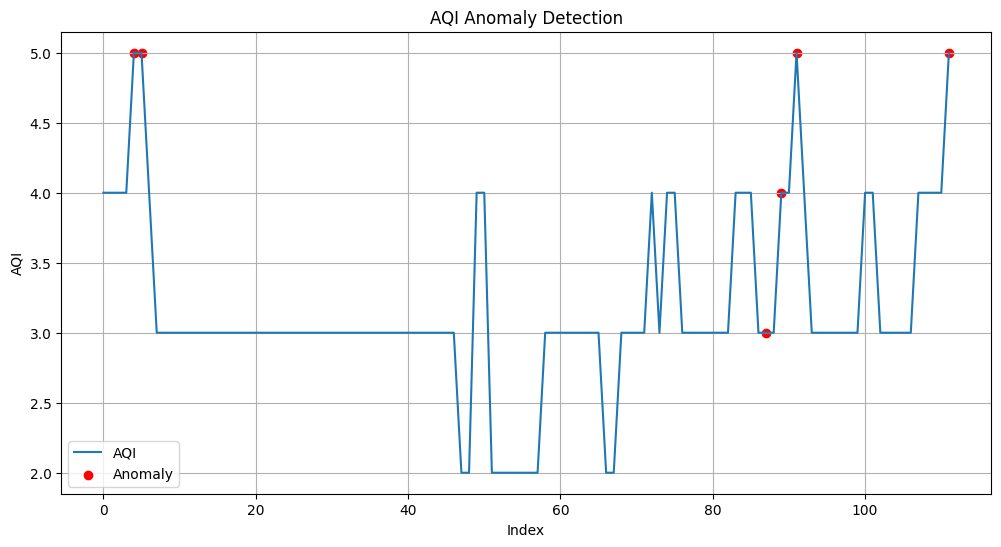

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["aqi"], label="AQI")

plt.scatter(
    anomalies.index,
    anomalies["aqi"],
    color="red",
    label="Anomaly"
)

plt.title("AQI Anomaly Detection")

plt.xlabel("Index")

plt.ylabel("AQI")

plt.legend()

plt.grid(True)

plt.show()

In [10]:
df.to_csv(
    "../data/anomaly_results.csv",
    index=False
)

In [11]:
df.to_sql(
    "anomaly_results",
    conn,
    if_exists="replace",
    index=False
)

112

In [12]:
import joblib

joblib.dump(
    model,
    "saved_models/isolation_forest.pkl"
)

['saved_models/isolation_forest.pkl']

In [13]:
model = joblib.load(
    "saved_models/isolation_forest.pkl"
)

In [14]:
sample = pd.DataFrame({
    "aqi":[4],
    "pm2_5":[180],
    "pm10":[200],
    "co":[900],
    "no2":[80],
    "o3":[40],
    "so2":[20]
})

prediction = model.predict(sample)

print(prediction)

[-1]
